# Data exploration

In [1]:
import pandas as pd
df = pd.read_csv("simulation_output.csv")

C:\Users\tobia\AppData\Local\Temp\ipykernel_2540\2607982420.py:2: DtypeWarning: Columns (18,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("simulation_output.csv")


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

data = df

data['WeekStartDate'] = pd.to_datetime(data['WeekStartDate'])

In [3]:
df.head()

,ReservableOptionMarketGroupId,WeekBeforeArrival,WeekStartDate,MarketGroupCode,BrandGroupCode,CampsiteCode,AccoKindCode,AccoTypeRangeCode,SpecialPeriodCode,SeasonalCluster,CampsiteCluster,CampsiteCountry,CampsiteRegion,CampsiteType,AccommodationType,AccommodationRange,Airco,Bedrooms,DeckingType,HotTub,Tropical,Roof,Kitchen,DeckingExtras,Bathrooms,Sleeps,TV,ArrivalMonth,DiscountedPrice,DiscountedPriceLastYear,HistoricalBookedNights,HistoricalBookedNightsLastYear,TotalBookedNights,Capacity,CapacityLastYear,latitude,longitude,AvgTemperature
0,Domestic-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,Froakie,Lental,Alola,Cabin,All-Inclusive,Budget,0,2,Tile,0,0,Canvas,Gourmet,BBQ,1,234,0,1,145.38,0.0,1,0,20,234,0,35.2708,22.4478,12.0
1,DACH-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,Froakie,Lental,Alola,Cabin,All-Inclusive,Budget,0,2,Tile,0,0,Canvas,Gourmet,BBQ,1,234,0,1,145.38,0.0,2,0,63,234,0,35.2708,22.4478,12.0
2,Benelux-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,Benelux,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,Froakie,Lental,Alola,Cabin,All-Inclusive,Budget,0,2,Tile,0,0,Canvas,Gourmet,BBQ,1,234,0,1,145.38,0.0,0,0,32,234,0,35.2708,22.4478,12.0
3,Rest of Europe-Thundurus-Meditite-Mobile-2024-...,52,2024-01-01,Rest of Europe,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,Froakie,Lental,Alola,Cabin,All-Inclusive,Budget,0,2,Tile,0,0,Canvas,Gourmet,BBQ,1,234,0,1,145.38,0.0,0,0,17,234,0,35.2708,22.4478,12.0
4,Domestic-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,Froakie,Lental,Alola,Cabin,All-Inclusive,Budget,0,2,Tile,0,0,Canvas,Gourmet,BBQ,1,234,0,1,145.38,0.0,0,0,20,234,0,35.2708,22.4478,12.0


In [ ]:
cols = df.columns.tolist()

print(cols)

['ReservableOptionMarketGroupId', 'WeekBeforeArrival', 'WeekStartDate', 'MarketGroupCode', 'BrandGroupCode', 'CampsiteCode', 'AccoKindCode', 'AccoTypeRangeCode', 'SpecialPeriodCode', 'SeasonalCluster', 'CampsiteCluster', 'CampsiteCountry', 'CampsiteRegion', 'CampsiteType', 'AccommodationType', 'AccommodationRange', 'Airco', 'Bedrooms', 'DeckingType', 'HotTub', 'Tropical', 'Roof', 'Kitchen', 'DeckingExtras', 'Bathrooms', 'Sleeps', 'TV', 'ArrivalMonth', 'DiscountedPrice', 'DiscountedPriceLastYear', 'HistoricalBookedNights', 'HistoricalBookedNightsLastYear', 'TotalBookedNights', 'Capacity', 'CapacityLastYear', 'latitude', 'longitude', 'AvgTemperature']


## Exploratieve Analyse — ECG / ORTEC pricing dataset

Verwacht een DataFrame `data` in de namespace.

**Doel:**
1. Begrijpen wat één rij is en hoe het dataset gestructureerd is
2. Detecteren van data quality issues (missing, outliers, gekke waarden)
3. Visualiseren van boekingscurves om intuïtie op te bouwen
4. Eerste signalen oppikken voor feature engineering en modelkeuze
5. Leakage-risico's vroeg in beeld krijgen

Run de blokken één voor één — niet alles in één keer. Stop, kijk naar de output, denk na.


BLOK 4 — Boekingscurves visualiseren


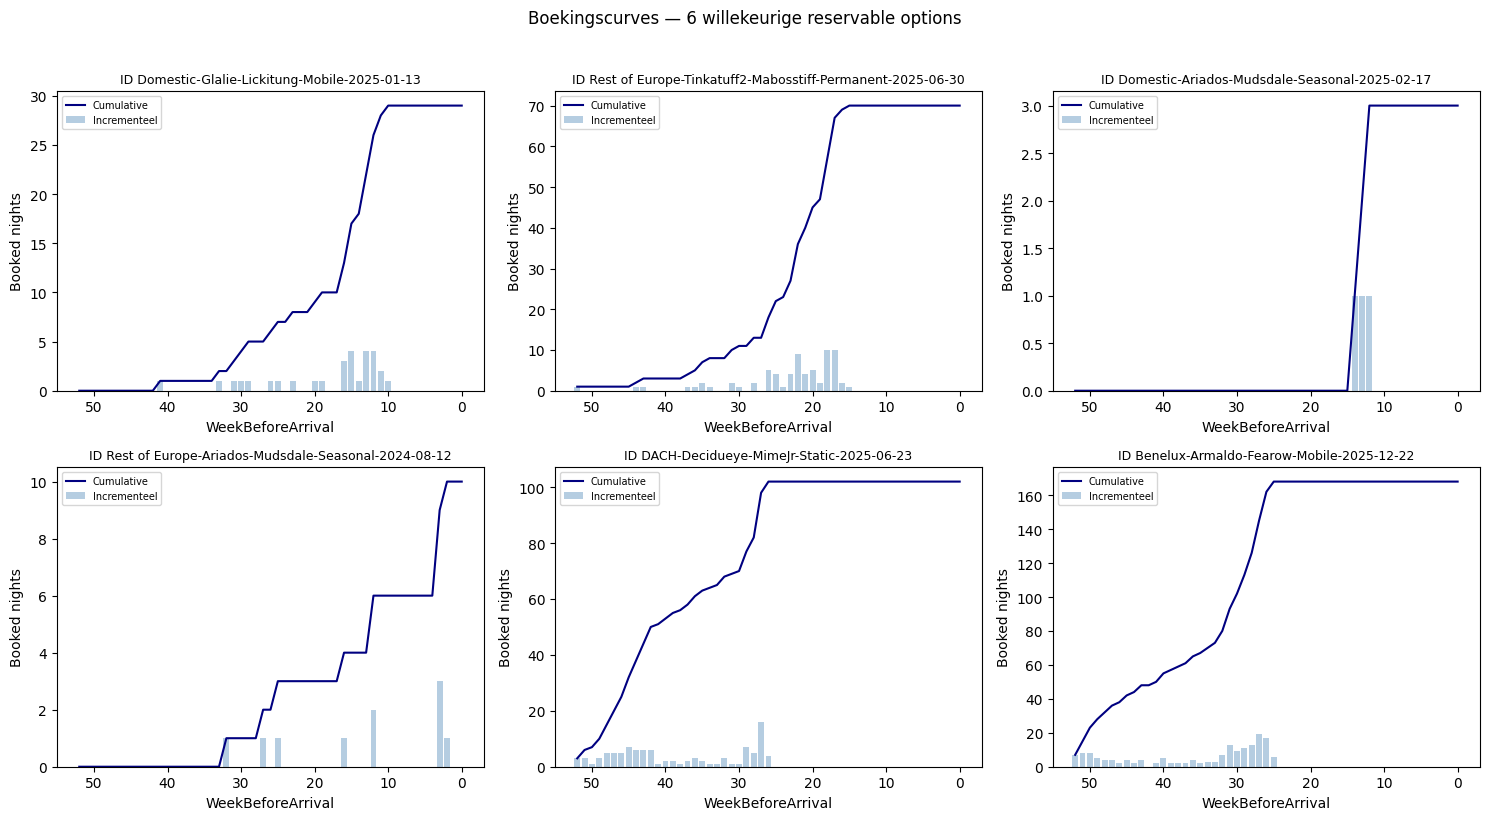

→ booking_curves_sample.png opgeslagen

Check: sum(HistoricalBookedNights) vs TotalBookedNights
count    59072.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: diff, dtype: float64
→ Als diff rond 0 ligt, klopt de relatie. Anders: vraagstuk in data.


In [ ]:
# BLOK 4 — Plot een paar boekingscurves
print('\n' + '=' * 70)
print('BLOK 4 — Boekingscurves visualiseren')
print('=' * 70)

sample_ids = (data['ReservableOptionMarketGroupId']
              .drop_duplicates()
              .sample(6, random_state=42)
              .tolist())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, rid in zip(axes.flat, sample_ids):
    sub = (data[data['ReservableOptionMarketGroupId'] == rid]
           .sort_values('WeekBeforeArrival', ascending=False)
           .copy())
    sub['CumulativeBookedNights'] = sub['HistoricalBookedNights'].cumsum()
    ax.plot(sub['WeekBeforeArrival'], sub['CumulativeBookedNights'], label='Cumulative', color='navy')
    ax.bar(sub['WeekBeforeArrival'], sub['HistoricalBookedNights'], alpha=0.4, color='steelblue', label='Incrementeel')
    ax.invert_xaxis()
    ax.set_title(f'ID {rid}', fontsize=9)
    ax.set_xlabel('WeekBeforeArrival')
    ax.set_ylabel('Booked nights')
    ax.legend(fontsize=7)

plt.suptitle('Boekingscurves — 6 willekeurige reservable options', y=1.02)
plt.tight_layout()
plt.savefig('booking_curves_sample.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ booking_curves_sample.png opgeslagen')

check = (data.groupby('ReservableOptionMarketGroupId')
             .agg(sum_incr=('HistoricalBookedNights', 'sum'),
                  total=('TotalBookedNights', 'first')))
check['diff'] = check['sum_incr'] - check['total']
print('\nCheck: sum(HistoricalBookedNights) vs TotalBookedNights')
print(check['diff'].describe())
print('→ Als diff rond 0 ligt, klopt de relatie. Anders: vraagstuk in data.')


BLOK 5 — Prijsdynamiek


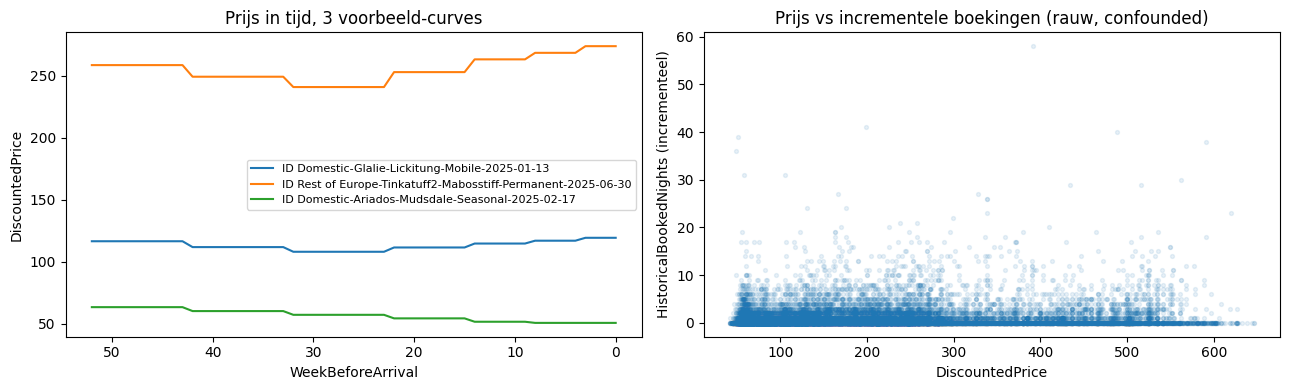

→ price_dynamics.png opgeslagen

Verdeling van DiscountedPrice / DiscountedPriceLastYear:


g:\My Drive\Statistiek\Semester 2\Statistical Consulting\Statistical_Consulting_Case\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


count    3130816.0
mean           inf
std            NaN
min            inf
25%            NaN
50%            NaN
75%            NaN
max            inf
Name: PriceRatioVsLastYear, dtype: float64


g:\My Drive\Statistiek\Semester 2\Statistical Consulting\Statistical_Consulting_Case\.venv\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [ ]:
# BLOK 5 — Prijsverloop & price elasticity (eerste blik)
print('\n' + '=' * 70)
print('BLOK 5 — Prijsdynamiek')
print('=' * 70)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for rid in sample_ids[:3]:
    sub = (data[data['ReservableOptionMarketGroupId'] == rid]
           .sort_values('WeekBeforeArrival', ascending=False))
    axes[0].plot(sub['WeekBeforeArrival'], sub['DiscountedPrice'], label=f'ID {rid}')
axes[0].invert_xaxis()
axes[0].set_xlabel('WeekBeforeArrival')
axes[0].set_ylabel('DiscountedPrice')
axes[0].set_title('Prijs in tijd, 3 voorbeeld-curves')
axes[0].legend(fontsize=8)

sample = data.sample(min(20000, len(data)), random_state=0)
axes[1].scatter(sample['DiscountedPrice'], sample['HistoricalBookedNights'], alpha=0.1, s=8)
axes[1].set_xlabel('DiscountedPrice')
axes[1].set_ylabel('HistoricalBookedNights (incrementeel)')
axes[1].set_title('Prijs vs incrementele boekingen (rauw, confounded)')

plt.tight_layout()
plt.savefig('price_dynamics.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ price_dynamics.png opgeslagen')

data['PriceRatioVsLastYear'] = data['DiscountedPrice'] / data['DiscountedPriceLastYear']
print('\nVerdeling van DiscountedPrice / DiscountedPriceLastYear:')
print(data['PriceRatioVsLastYear'].describe())

In [ ]:
# BLOK 6 — Vorig jaar als baseline-indicator
print('\n' + '=' * 70)
print('BLOK 6 — Vorig jaar als signaal')
print('=' * 70)

corr_total = data.groupby('ReservableOptionMarketGroupId').agg(
    total_now=('TotalBookedNights', 'first'),
    cap_now=('Capacity', 'first'),
    cap_ly=('CapacityLastYear', 'first'),
)
total_ly = (data.groupby('ReservableOptionMarketGroupId')['HistoricalBookedNightsLastYear'].sum()
            .rename('total_ly'))
corr_total = corr_total.join(total_ly)

print(corr_total.describe())
print('\nCorrelatie tussen totale boekingen dit jaar en vorig jaar:')
print(corr_total[['total_now', 'total_ly']].corr().iloc[0, 1])


BLOK 6 — Vorig jaar als signaal
          total_now       cap_now   cap_ly  total_ly
count  59072.000000  59072.000000  59072.0   59072.0
mean      49.405234    346.566901      0.0       0.0
std       56.684795    159.113250      0.0       0.0
min        0.000000    105.000000      0.0       0.0
25%        8.000000    228.000000      0.0       0.0
50%       31.000000    324.000000      0.0       0.0
75%       71.000000    435.000000      0.0       0.0
max      565.000000    950.000000      0.0       0.0

Correlatie tussen totale boekingen dit jaar en vorig jaar:
nan



BLOK 7 — Seizoen
              avg_total   avg_price   avg_temp
ArrivalMonth                                  
1             35.443662  207.456389   4.415493
2              7.863996  196.782538   5.087324
3             64.206182  218.390454   7.928169
4             66.258803  219.968867  11.153521
5             44.310519  213.820430  15.292254
6             69.766432  219.325682  19.052113
7             82.202660  221.744557  21.518310
8             82.380942  221.571190  21.132394
9             29.653345  209.734981  17.539437
10            41.015845  213.376335  12.980986
11             2.064921  194.366409   8.366901
12            62.180164  213.462577   5.442254


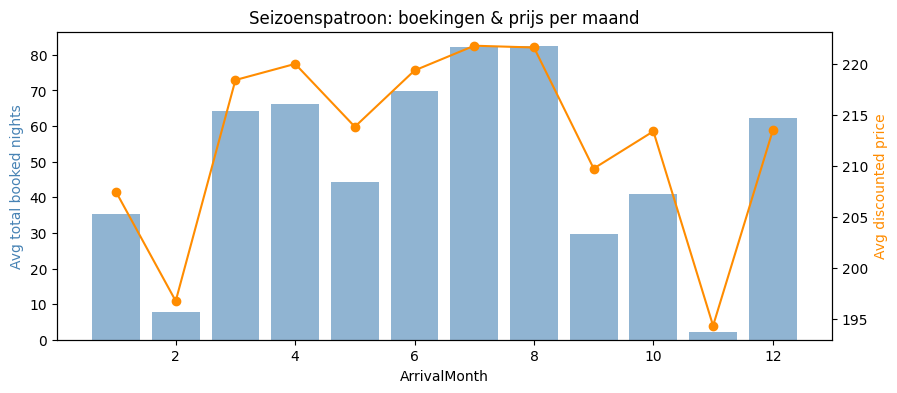

→ seasonality.png opgeslagen


In [ ]:
# BLOK 7 — Seizoenspatroon
print('\n' + '=' * 70)
print('BLOK 7 — Seizoen')
print('=' * 70)

monthly = (data.groupby('ArrivalMonth')
               .agg(avg_total=('TotalBookedNights', 'mean'),
                    avg_price=('DiscountedPrice', 'mean'),
                    avg_temp=('AvgTemperature', 'mean')))
print(monthly)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(monthly.index, monthly['avg_total'], alpha=0.6, color='steelblue', label='Avg total bookings')
ax2.plot(monthly.index, monthly['avg_price'], color='darkorange', marker='o', label='Avg price')
ax1.set_xlabel('ArrivalMonth')
ax1.set_ylabel('Avg total booked nights', color='steelblue')
ax2.set_ylabel('Avg discounted price', color='darkorange')
plt.title('Seizoenspatroon: boekingen & prijs per maand')
plt.savefig('seasonality.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ seasonality.png opgeslagen')

In [ ]:
# BLOK 8 — Leakage waarschuwingen
print('\n' + '=' * 70)
print('BLOK 8 — Leakage check')
print('=' * 70)

leakage_risk = {
    'TotalBookedNights':
        'Eindstand — bekend NA de aankomstweek. Mag NOOIT als feature, alleen als target.',
    'Capacity':
        'Per accommodatie constant in tijd — meestal veilig, maar check of het ooit mid-season verandert.',
    'DiscountedPrice':
        'Prijs op snapshot-moment is OK als feature. Toekomstige prijzen niet.',
    'HistoricalBookedNights':
        'Boekingen op huidige snapshot zijn OK; toekomstige niet (dat is je target).',
    'AvgTemperature':
        'Als dit *gemeten* is op de stay-week → leakage voor lange-termijn voorspellingen. '
        'Als dit *forecast* is → veilig. Vraag dit na bij ORTEC.',
}
for k, v in leakage_risk.items():
    if k in data.columns:
        print(f'  ⚠ {k}: {v}')


BLOK 8 — Leakage check
  ⚠ TotalBookedNights: Eindstand — bekend NA de aankomstweek. Mag NOOIT als feature, alleen als target.
  ⚠ Capacity: Per accommodatie constant in tijd — meestal veilig, maar check of het ooit mid-season verandert.
  ⚠ DiscountedPrice: Prijs op snapshot-moment is OK als feature. Toekomstige prijzen niet.
  ⚠ HistoricalBookedNights: Boekingen op huidige snapshot zijn OK; toekomstige niet (dat is je target).
  ⚠ AvgTemperature: Als dit *gemeten* is op de stay-week → leakage voor lange-termijn voorspellingen. Als dit *forecast* is → veilig. Vraag dit na bij ORTEC.


In [35]:
# BLOK 9 — Tijdsdekking & valid split-keuzes
print('\n' + '=' * 70)
print('BLOK 9 — Tijdsdekking voor train/val split')
print('=' * 70)

data['StayYear'] = data['WeekStartDate'].dt.year
data['StayWeek'] = data['WeekStartDate'].dt.isocalendar().week
print('Aantal rijen per stay-jaar:')
print(data['StayYear'].value_counts().sort_index())

print('\nAantal unieke (jaar, week) combinaties:')
print(data.groupby(['StayYear', 'StayWeek']).ngroups)

cutoff = data['WeekStartDate'].quantile(0.8)
print(f'\nVoorgestelde cutoff (80e percentiel van WeekStartDate): {cutoff}')
print(f'  Train rijen: {(data["WeekStartDate"] < cutoff).sum()}')
print(f'  Val rijen:   {(data["WeekStartDate"] >= cutoff).sum()}')


BLOK 9 — Tijdsdekking voor train/val split
Aantal rijen per stay-jaar:
StayYear
2024    1595512
2025    1535304
Name: count, dtype: int64

Aantal unieke (jaar, week) combinaties:
103

Voorgestelde cutoff (80e percentiel van WeekStartDate): 2025-08-04 00:00:00
  Train rijen: 2498632
  Val rijen:   632184


# Eerste model — XGBoost

**Target:** `TotalBookedNights` (eindstand boekingen per curve)  
**Split:** time-based op `WeekStartDate` (80/20)  
**Features:** beperkte set om een baseline te hebben — uitbreiden na EDA

In [4]:
# data["DiscountedPriceLastYear"].describe()
# drop feature

Snapshots bij WeekBeforeArrival=8: 59072 rijen
Train: 47144 | Val: 11928
[0]	validation_0-rmse:54.66891
[50]	validation_0-rmse:41.94810
[100]	validation_0-rmse:40.09621
[150]	validation_0-rmse:39.60500
[200]	validation_0-rmse:39.37662
[250]	validation_0-rmse:39.27063
[300]	validation_0-rmse:39.19266
[350]	validation_0-rmse:39.14758
[399]	validation_0-rmse:39.11556

Val MAE  (model): 25.37
Val RMSE (model): 39.12
Val MAE  (naïef vorig jaar): 42.96
Verbetering t.o.v. naïef: 40.9%


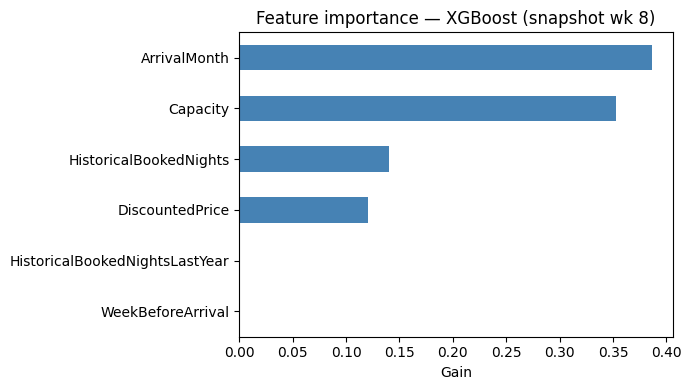

In [5]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# --- één rij per curve: neem snapshot op WeekBeforeArrival == 8 (2 maanden voor aankomst)
# pas SNAPSHOT_WEEK aan naargelang welk voorspelmoment je wilt testen
SNAPSHOT_WEEK = 8

snap = data[data['WeekBeforeArrival'] == SNAPSHOT_WEEK].copy()
print(f'Snapshots bij WeekBeforeArrival={SNAPSHOT_WEEK}: {len(snap)} rijen')

# --- features & target
FEATURES = [
    'WeekBeforeArrival',          # altijd dezelfde waarde hier, maar makkelijk te wisselen
    'HistoricalBookedNights',     # boekingen tot nu toe
    'HistoricalBookedNightsLastYear',
    'DiscountedPrice',
    'Capacity',
    'ArrivalMonth',
]
FEATURES = [f for f in FEATURES if f in snap.columns]
TARGET = 'TotalBookedNights'

snap = snap.dropna(subset=FEATURES + [TARGET])

# --- time-based split (geen random split — dat zou data leaken via seizoen)
cutoff = snap['WeekStartDate'].quantile(0.8)
train = snap[snap['WeekStartDate'] < cutoff]
val   = snap[snap['WeekStartDate'] >= cutoff]
print(f'Train: {len(train)} | Val: {len(val)}')

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]

# --- model
model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

# --- evaluatie
pred_val = model.predict(X_val)
mae  = mean_absolute_error(y_val, pred_val)
rmse = root_mean_squared_error(y_val, pred_val)
naive_mae = mean_absolute_error(y_val, val['HistoricalBookedNightsLastYear'])

print(f'\nVal MAE  (model): {mae:.2f}')
print(f'Val RMSE (model): {rmse:.2f}')
print(f'Val MAE  (naïef vorig jaar): {naive_mae:.2f}')
print(f'Verbetering t.o.v. naïef: {(naive_mae - mae) / naive_mae * 100:.1f}%')

# --- feature importance
fi = (pd.Series(model.feature_importances_, index=FEATURES)
        .sort_values(ascending=True))
fig, ax = plt.subplots(figsize=(7, 4))
fi.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Feature importance — XGBoost (snapshot wk {SNAPSHOT_WEEK})')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()